<a href="https://colab.research.google.com/github/Priyanshi07-ai/synthetic_medical_diagnosis_records/blob/main/Welcome_to_Colab_(3)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### PROJECT NAME - GENERATING SYNTHETIC MEDICAL DIAGNOSIS RECORDS

#### CONTRIBUTION - INDIVIDUAL NAME - PRIYANSHI BHANDARI

### SUMMARY: GENERATING SYNTHETIC MEDICAL DIAGNOSIS RECORDS

#### This project focuses on improving disease prediction using Machine Learning and Synthetic Data Augmentation. Three medical datasets were used: heart disease, diabetes, and liver disease. Initially, the datasets were small and imbalanced, meaning healthy cases were much higher than disease cases. This imbalance causes machine learning models to become biased and perform poorly in detecting actual patients.
#### To solve this, data preprocessing and exploratory data analysis were performed. Missing values were handled, categorical features were converted into numerical form, and important medical features such as age, blood pressure, cholesterol, BMI, and glucose were selected.
#### A Random Forest Classifier was trained on the original datasets to establish baseline accuracy. After this, CTGAN (Conditional Tabular GAN) was used to generate synthetic data for the minority class. CTGAN learns patterns from real patient records and creates realistic artificial patients. The real and synthetic data were then combined to form augmented datasets.
#### The machine learning models were retrained using the augmented datasets. Accuracy of models trained on real data and augmented data were compared. Results showed improved performance when synthetic data was used. Finally, trained models were saved and deployed using Streamlit to create a user interface for disease prediction.

### OBJECTIVE

#### Main objectives of the project are:

#### 1 To build machine learning models for predicting heart disease, diabetes, and liver disease
#### 2 To handle class imbalance in medical datasets
#### 3 To generate synthetic minority data using CTGAN
#### 4To compare model performance on real vs augmented datasets
#### 5 To improve disease prediction accuracy using data augmentation
#### 6 To deploy trained models using Streamlit for real-time prediction

### Library import

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

### DATASET

In [ ]:
heart = pd.read_csv("heart_disease_uci.csv")
diabetes = pd.read_csv("diabetes.csv")
liver = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv", header=None)

### EDA ON ALL THREE DATASET

In [ ]:
heart.info()
liver.info()
heart.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column  Non-Null Co

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
diabetes.info()
diabetes.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
liver.info()
liver.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       583 non-null    int64  
 1   1       583 non-null    object 
 2   2       583 non-null    float64
 3   3       583 non-null    float64
 4   4       583 non-null    int64  
 5   5       583 non-null    int64  
 6   6       583 non-null    int64  
 7   7       583 non-null    float64
 8   8       583 non-null    float64
 9   9       579 non-null    float64
 10  10      583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


,0,1,2,3,4,5,6,7,8,9,10
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


### DATA CLEANING

In [ ]:
# Convert sex
heart['Gender'] = heart['sex'].map({'Male': 0, 'Female': 1})
heart['target'] = heart['num']
heart = heart.drop(columns=['sex', 'num'])
# Same for other categorical columns
for col in heart.select_dtypes(include='object').columns:
    heart[col] = heart[col].astype('category').cat.codes

In [ ]:
liver.columns = [
    'Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
    'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
    'Aspartate_Aminotransferase', 'Total_Proteins',
    'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset'
]
liver['Gender'] = liver['Gender'].map({'Male': 0, 'Female': 1})
liver['target'] = liver['Dataset']
liver= liver.drop('Dataset', axis=1)

In [ ]:
heart = heart.apply(pd.to_numeric, errors='coerce')
heart = heart.dropna()

liver = liver.apply(pd.to_numeric, errors='coerce')
liver = liver.dropna()

In [ ]:
heart['target'] = heart['target'].apply(lambda x: 1 if x > 0 else 0)
liver['target'] = liver['target'].apply(lambda x: 1 if x == 2 else 0)

In [ ]:
diabetes['target'] = diabetes['Outcome']
diabetes = diabetes.drop('Outcome', axis=1)

In [ ]:
print('heart')
heart.info()
print('diabetes')
diabetes.info()
print('liver')
liver.info()

heart
<class 'pandas.core.frame.DataFrame'>
Index: 308 entries, 0 to 759
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        308 non-null    int64  
 1   age       308 non-null    int64  
 2   dataset   308 non-null    int8   
 3   cp        308 non-null    int8   
 4   trestbps  308 non-null    float64
 5   chol      308 non-null    float64
 6   fbs       308 non-null    int8   
 7   restecg   308 non-null    int8   
 8   thalch    308 non-null    float64
 9   exang     308 non-null    int8   
 10  oldpeak   308 non-null    float64
 11  slope     308 non-null    int8   
 12  ca        308 non-null    float64
 13  thal      308 non-null    int8   
 14  Gender    308 non-null    int64  
 15  target    308 non-null    int64  
dtypes: float64(5), int64(4), int8(7)
memory usage: 26.2 KB
diabetes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column        

### BAR GRAPGH

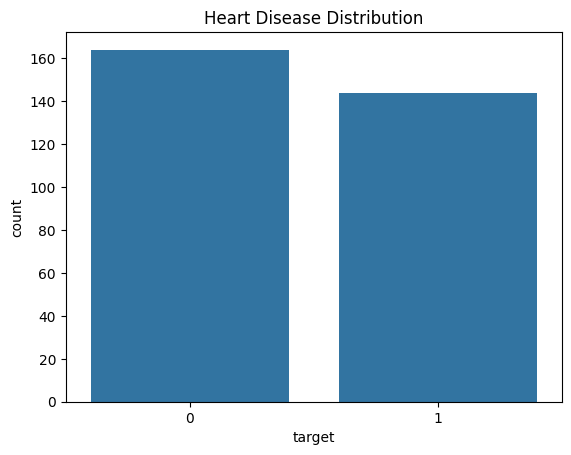

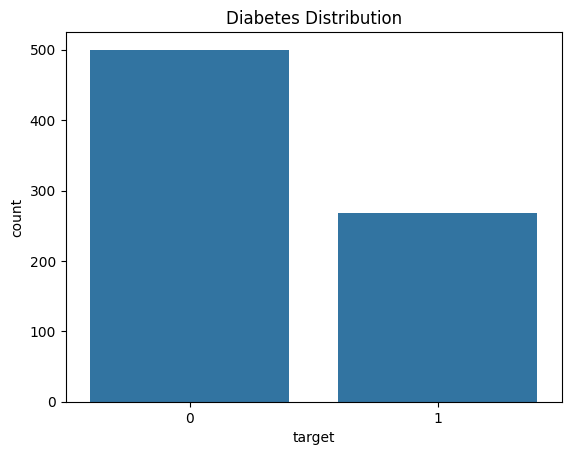

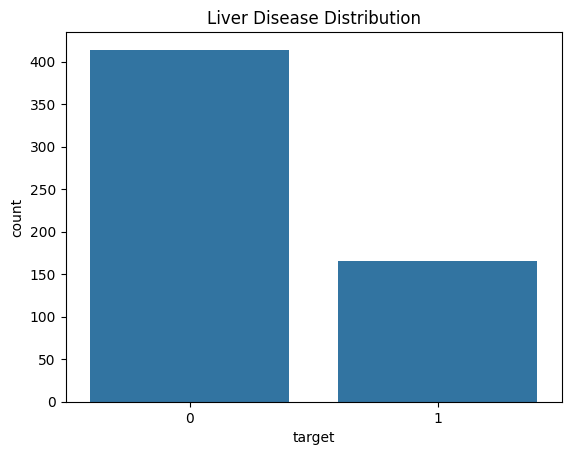

In [ ]:
# Class distribution
sns.countplot(x='target', data=heart)
plt.title("Heart Disease Distribution")
plt.show()

sns.countplot(x='target', data=diabetes)
plt.title("Diabetes Distribution")
plt.show()

sns.countplot(x='target', data=liver)
plt.title("Liver Disease Distribution")
plt.show()

### HEATMAP

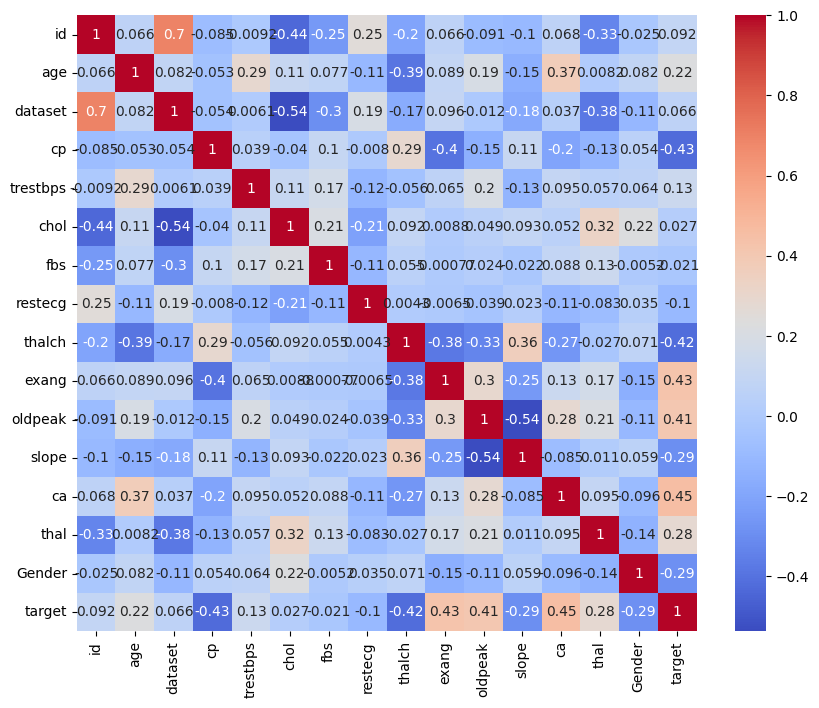

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(heart.corr(), annot=True, cmap='coolwarm')
plt.show()

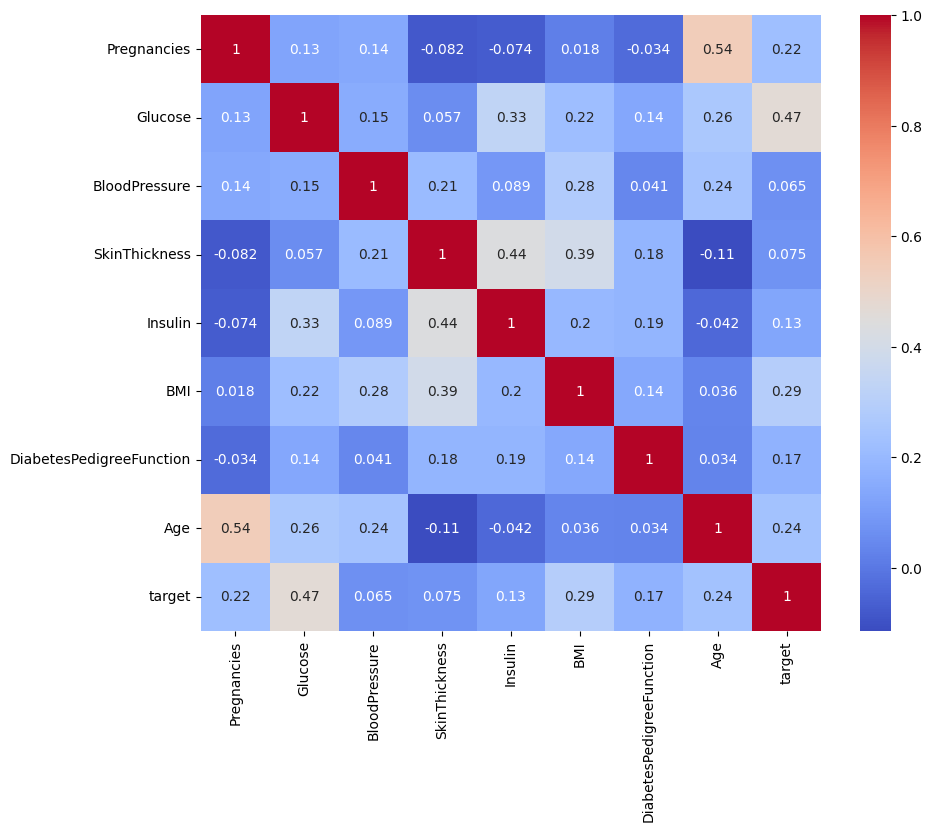

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(diabetes.corr(), annot=True, cmap='coolwarm')
plt.show()

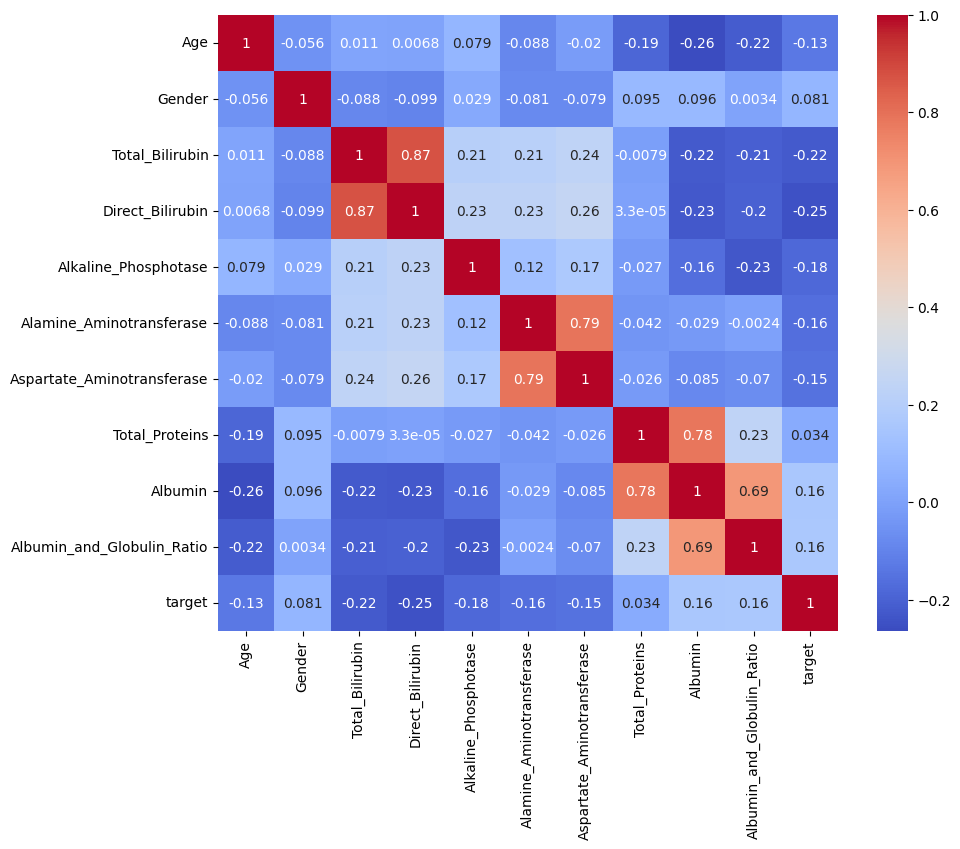

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(liver.corr(), annot=True, cmap='coolwarm')
plt.show()

### FEATURE ENGINEER

In [ ]:
heart = heart[['age','Gender','trestbps','chol','thalch','oldpeak','target']]
heart = heart.rename(columns={
    'sex': 'gender',
    'trestbps': 'bp',
    'chol': 'cholesterol'
})
diabetes = diabetes[['Age','Glucose','BloodPressure','BMI','target']]
diabetes = diabetes.rename(columns={
    'Age': 'age',
    'Glucose': 'glucose',
    'BloodPressure': 'bp',
    'BMI': 'bmi'
})
liver = liver[['Age','Gender','Total_Bilirubin','Alkaline_Phosphotase','Albumin','target']]
liver = liver.rename(columns={
    'Age': 'age',
    'Gender': 'gender',
    'Total_Bilirubin': 'bilirubin',
    'Alkaline_Phosphotase': 'alk_phosphate',
    'Albumin': 'albumin'
})

### MODEL TRAING FUNCTION (USING RANDOMFORESTCLASSIFIER MODEL)

In [ ]:
def train_model(df, target):
    X = df.drop(target, axis=1)
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    model = RandomForestClassifier()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    return model, acc, X_test, y_test

### TRAINING ON REAL DATASET

In [ ]:
heart_model_real, heart_acc_real, hea_real_x, hea_real_y = train_model(heart, 'target')

In [ ]:
diabetes_model_real, diabetes_acc_real, dia_real_x, dia_real_y = train_model(diabetes, 'target')

In [ ]:
liver_model_real, liver_acc_real, liv_real_x, liv_real_y = train_model(liver, 'target')

### USING SDV CTGAN for SYNTHETIC DATASET

#### MAJORITY MINORITY DISTRIBUTION

In [ ]:
# count class distribution
print(heart['target'].value_counts())
print(diabetes['target'].value_counts())
print(liver['target'].value_counts())

target
0    164
1    144
Name: count, dtype: int64
target
0    500
1    268
Name: count, dtype: int64
target
0    414
1    165
Name: count, dtype: int64


In [ ]:
minority_hea = heart[heart['target'] == 1]
minority_dia =diabetes[diabetes['target'] == 1]
minority_liv = liver[liver['target']==1]

### FOR HEART

In [ ]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# Create metadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data = minority_hea)

# Create model
ctgan = CTGANSynthesizer(metadata=metadata, epochs=200, verbose = True)

# Train
ctgan.fit(minority_hea)

# Generate synthetic data
synthetic_heart = ctgan.sample(num_rows=1000)

print(synthetic_heart.head())

C:\Users\Priyanshi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sdv\single_table\base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
C:\Users\Priyanshi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sdv\single_table\base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-01.05) | Discrim. (-00.07): 100%|█████████████████████████████████████████████| 200/200 [00:21<00:00,  9.52it/s]


   age  Gender     bp  cholesterol  thalch  oldpeak  target
0   68       1  113.0        309.0   141.0      0.2       1
1   63       0  116.0        156.0   150.0     -0.4       1
2   64       1  116.0        275.0   164.0      2.8       1
3   72       0  189.0        318.0   104.0      1.0       1
4   66       0  135.0        258.0   152.0     -0.8       1


### FOR DIABETES

In [ ]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# Create metadata)
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data = minority_dia)

# Create model
ctgan = CTGANSynthesizer(metadata=metadata, epochs=200, verbose = True)

# Train
ctgan.fit(minority_dia)

# Generate synthetic data
synthetic_diabetes = ctgan.sample(num_rows=1000)

print(synthetic_diabetes.head())

C:\Users\Priyanshi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sdv\single_table\base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
C:\Users\Priyanshi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sdv\single_table\base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-01.33) | Discrim. (+00.22): 100%|█████████████████████████████████████████████| 200/200 [00:23<00:00,  8.47it/s]


   age  glucose  bp   bmi  target
0   40      138  47  26.7       1
1   26      145  20  30.4       1
2   53      106  71  37.3       1
3   28      198  68  25.1       1
4   35      199  71  27.2       1


### FOR LIVER

In [ ]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# Create metadata)
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data = minority_liv)

# Create model
ctgan = CTGANSynthesizer(metadata=metadata, epochs=200, verbose = True)

# Train
ctgan.fit(minority_liv)

# Generate synthetic data
synthetic_liver = ctgan.sample(num_rows=1000)

print(synthetic_liver.head())

C:\Users\Priyanshi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sdv\single_table\base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
C:\Users\Priyanshi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sdv\single_table\base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-01.05) | Discrim. (+00.17): 100%|█████████████████████████████████████████████| 200/200 [00:29<00:00,  6.79it/s]


   age  gender  bilirubin  alk_phosphate  albumin  target
0   65       1        1.0            223      2.6       1
1   30       0        1.1            156      5.0       1
2   47       1        1.0            458      3.7       1
3   43       1        0.5            154      5.0       1
4   85       0        1.1            170      5.0       1


### AUGMENTED DATASET MODEL AND REAL DATASET MODEL COMPARISION

In [ ]:
heart_aug = pd.concat([heart, synthetic_heart], ignore_index=True)

In [ ]:
heart_model_aug, heart_acc_aug, X_aug_heart, y_aug_heart  = train_model(heart_aug, 'target')

In [ ]:
print("Heart Accuracy (Real):", heart_acc_real)
print("Heart Accuracy (Augmented):", heart_acc_aug)

Heart Accuracy (Real): 0.6935483870967742
Heart Accuracy (Augmented): 0.8931297709923665


In [ ]:
diabetes_aug = pd.concat([diabetes, synthetic_diabetes], ignore_index=True)

In [ ]:
diabetes_model_aug, diabetes_acc_aug, X_aug_diabetes, y_aug_diabetes = train_model(diabetes_aug, 'target')

In [ ]:
print("diabetes Accuracy (Real):", diabetes_acc_real)
print("diabetes Accuracy (Augmented):", diabetes_acc_aug)

diabetes Accuracy (Real): 0.7142857142857143
diabetes Accuracy (Augmented): 0.8050847457627118


In [ ]:
liver_aug = pd.concat([liver, synthetic_liver], ignore_index=True)

In [ ]:
liver_model_aug, liver_acc_aug, X_aug_liver, y_aug_liver = train_model(liver_aug, 'target')

In [ ]:
print("liver Accuracy (Real):", liver_acc_real)
print("liver Accuracy (Augmented):", liver_acc_aug)

liver Accuracy (Real): 0.6982758620689655
liver Accuracy (Augmented): 0.8575949367088608


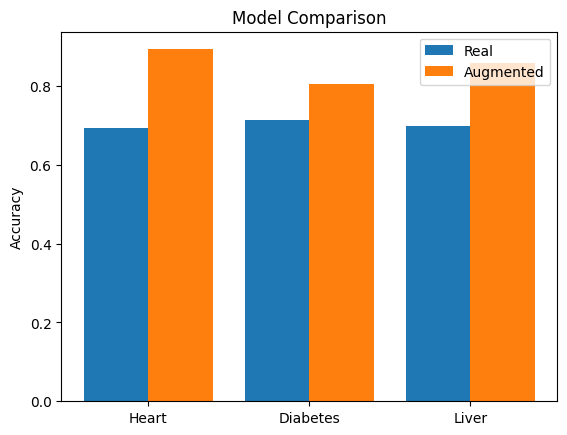

In [ ]:
labels = ['Heart', 'Diabetes', 'Liver']

real_acc = [heart_acc_real, diabetes_acc_real, liver_acc_real]
aug_acc = [heart_acc_aug, diabetes_acc_aug, liver_acc_aug]

import numpy as np

x = np.arange(len(labels))

plt.bar(x-0.2, real_acc, width=0.4, label='Real')
plt.bar(x+0.2, aug_acc, width=0.4, label='Augmented')

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Comparison")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, X_test, y_test, title="Confusion Matrix"):

    # Make predictions
    y_pred = model.predict(X_test)

    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(title)
    plt.show()

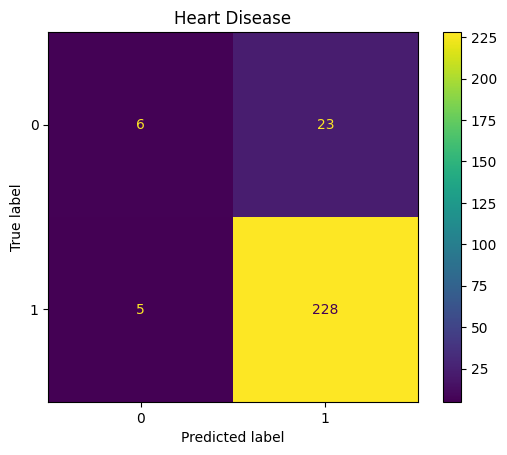

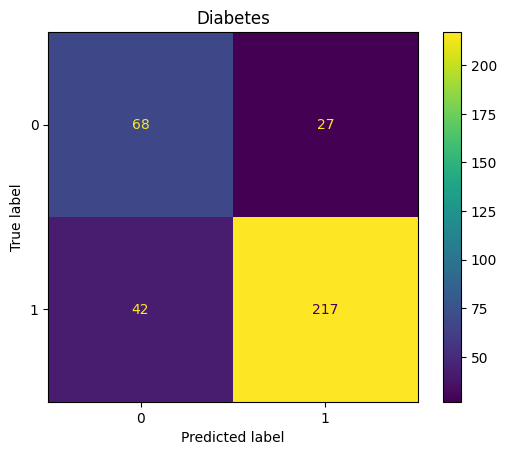

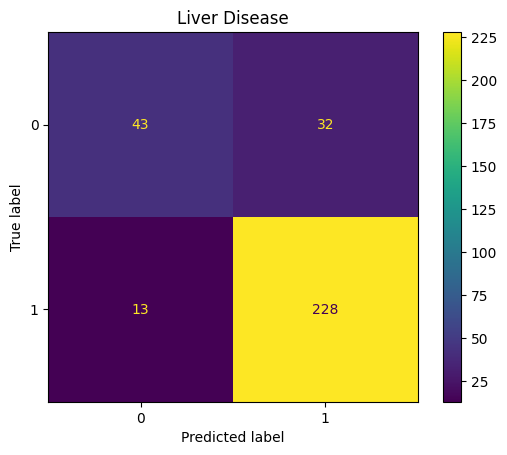

In [ ]:
plot_confusion_matrix(heart_model_aug, X_aug_heart, y_aug_heart, "Heart Disease")
plot_confusion_matrix(diabetes_model_aug, X_aug_diabetes, y_aug_diabetes, "Diabetes")
plot_confusion_matrix(liver_model_aug, X_aug_liver, y_aug_liver, "Liver Disease")

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib

def save(model, filename):
    joblib.dump(model, filename)

# Save
save(heart_model_aug, 'models/heart.pkl')
save(diabetes_model_aug, 'models/diabetes.pkl')
save(liver_model_aug, 'models/liver.pkl')

print("Models saved successfully!")

Models saved successfully!


### APP.PY

In [ ]:
# import streamlit as st
# import numpy as np
# import joblib

# st.title("Multi Disease Prediction")

# # Load models
# heart_model = joblib.load("models/heart.pkl")
# dia_model = joblib.load("models/diabetes.pkl")
# liv_model = joblib.load("models/liver.pkl")

# st.header("Enter Patient Details")

# #  ALL FEATURES COMBINED
# age = st.number_input("Age", value=None)
# gender = st.selectbox("Gender", ["Male", "Female"])
# bp = st.number_input("Blood Pressure (trestbps)", value=None)
# chol = st.number_input("Cholesterol", value=None)
# thalach = st.number_input("Max Heart Rate (thalach)", value=None)
# oldpeak = st.number_input("Oldpeak", value=None)

# glucose = st.number_input("Glucose", value=None)
# bmi = st.number_input("BMI", value=None)

# bilirubin = st.number_input("Total Bilirubin", value=None)
# alk = st.number_input("Alkaline Phosphotase", value=None)
# albumin = st.number_input("Albumin", value=None)

# # Convert gender
# gender_val = 1 if gender == "Male" else 0

# def format_output(value):
#     if value == 0:
#         return "Insufficient Data"
#     elif value < 50:
#         return "Normal"
#     else:
#         return f"{value:.2f}% Risk"

# # PREDICT
# if st.button("Predict"):

#     # HEART
#     if None not in [age, bp, chol, thalach, oldpeak]:
#         heart_input = np.array([[age, gender_val, bp, chol, thalach, oldpeak]])
#         heart_pred = heart_model.predict_proba(heart_input)[0][1]*100
#     else:
#         heart_pred = 0

#     # DIABETES
#     if None not in [age, glucose, bp, bmi]:
#         dia_input = np.array([[age, glucose, bp, bmi]])
#         dia_pred = dia_model.predict_proba(dia_input)[0][1]*100
#     else:
#         dia_pred = 0

#     # LIVER
#     if None not in [age, bilirubin, alk, albumin]:
#         liv_input = np.array([[age, gender_val, bilirubin, alk, albumin]])
#         liv_pred = liv_model.predict_proba(liv_input)[0][1]*100
#     else:
#         liv_pred = 0

#     # OUTPUT
# st.subheader("Results")

# st.write(f" Heart Disease: {format_output(heart_pred)}")
# st.write(f" Diabetes: {format_output(dia_pred)}")
# st.write(f" Liver Disease: {format_output(liv_pred)}")

2026-05-05 19:45:12.834 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 19:45:13.214 
  command:

    streamlit run C:\Users\Priyanshi\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-05 19:45:13.215 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 19:45:13.217 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 19:45:13.444 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 19:45:13.446 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 19:45:13.447 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 19

NameError: name 'heart_pred' is not defined

### CONCLUSION OF THE PROJECT

#### This project demonstrates that class imbalance significantly affects the performance of machine learning models in healthcare prediction tasks. Models trained on real datasets tend to become biased toward the majority class and fail to detect disease cases effectively.
#### By applying CTGAN, realistic synthetic patient data was generated for the minority class, which helped balance the datasets. After augmentation, the Random Forest models showed improved accuracy and better generalization.
#### The project proves that synthetic data generation is an effective technique for improving medical prediction systems. The deployment using Streamlit makes the solution user-friendly and practical for real-world applications.
